# Projeto Final - Segurança da Informação


Este caderno pretende utilizar 3 métodos de ataques adversariais para confundir um modelo pré-treinado classificador de imagens reais ou geradas artificialmente em acreditar que imagens artificiais sejam reais.

# I. Escolha do modelo

Iremos utilizar o modelo AI Image Detector do autor `umm-maybe`

In [1]:
import torch
from transformers import AutoImageProcessor, AutoModelForImageClassification
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# carregando modelo pré-treinado do Hugging Face
processor = AutoImageProcessor.from_pretrained("umm-maybe/AI-image-detector")
model = AutoModelForImageClassification.from_pretrained("umm-maybe/AI-image-detector")
model = model.to(device)
model.eval()

print("Classes do modelo:", model.config.id2label)

2025-12-18 13:35:27.131966: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-18 13:35:27.159510: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-18 13:35:27.827628: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


preprocessor_config.json:   0%|          | 0.00/240 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json:   0%|          | 0.00/937 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/348M [00:00<?, ?B/s]

Classes do modelo: {0: 'artificial', 1: 'human'}


model.safetensors:   0%|          | 0.00/347M [00:00<?, ?B/s]

In [19]:
# função de ataque FGSM
def fgsm_attack(image, epsilon, grad):
    sign_grad = grad.sign()
    # x_adv = x + epsilon * sign(gradiente)
    perturbed_image = image + epsilon * sign_grad
    # não usamos clamp(0,1) aqui porque a imagem está normalizada (tem valores negativos)
    return perturbed_image

In [ ]:
import kagglehub
# carrega dataset - imagem
path = kagglehub.dataset_download("cashbowman/ai-generated-images-vs-real-images")

folder_list = Path(path).rglob("*.jpg")


Imagem usada: /home/luis-menezes/.cache/kagglehub/datasets/cashbowman/ai-generated-images-vs-real-images/versions/1/AiArtData/AiArtData/a4411c44-c1cc-45ca-bf4b-2ecaf5172ba8.jpg


In [114]:
# pega a primeira imagem que encontrar
img_path = next(folder_list)
image = Image.open(img_path).convert("RGB")

print("Imagem usada:", img_path)

# pré-processa a imagem
inputs = processor(images=image, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

inputs["pixel_values"].requires_grad = True

outputs = model(**inputs)

orig_probs = torch.softmax(outputs.logits, dim=1)
orig_pred = orig_probs.argmax(dim=1).item()
orig_conf = orig_probs[0, orig_pred].item()
orig_label = model.config.id2label[orig_pred]

print(f"Original --> {model.config.id2label[orig_pred]} ({orig_conf:.4f})")

# cálculo do erro
loss = torch.nn.CrossEntropyLoss()(
    outputs.logits,
    outputs.logits.argmax(dim=1)
)

model.zero_grad()
loss.backward()

Imagem usada: /home/luis-menezes/.cache/kagglehub/datasets/cashbowman/ai-generated-images-vs-real-images/versions/1/AiArtData/AiArtData/hassan-ragab-cairo-sketches-midjourney-ai-architecture-hero_dezeen_1704_col_0.jpg
Original --> artificial (0.9774)


In [127]:
# aplicação do ataque FGSM
epsilon = 0.1 # inicialmente em 0.1, mas podemos aumentar
perturbed_data = fgsm_attack(inputs["pixel_values"], epsilon, inputs["pixel_values"].grad)

In [128]:
# pós ataque
with torch.no_grad():
    adv_outputs = model(pixel_values=perturbed_data)

adv_probs = torch.softmax(adv_outputs.logits, dim=1)
adv_pred_idx = adv_probs.argmax(dim=1).item()
adv_label = model.config.id2label[adv_pred_idx]
adv_conf = adv_probs[0, adv_pred_idx].item()

print(f"Pós-Ataque: {adv_label} ({adv_conf:.2%})")

if orig_label != adv_label:
    print("Success! Modelo enganado pela perturbação.")

Pós-Ataque: artificial (75.65%)


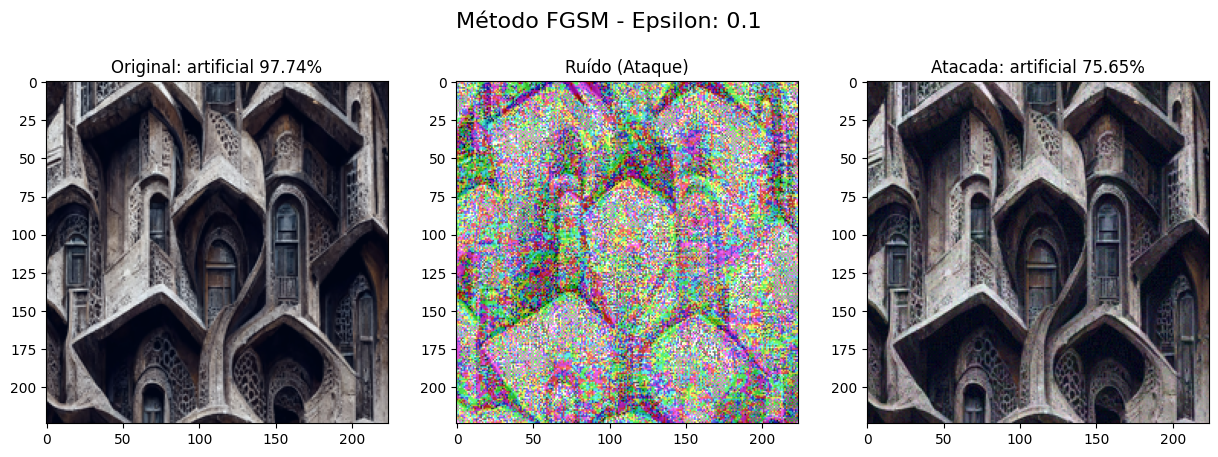

In [129]:
def show_comparison():
    # tira da GPU e converte para numpy
    orig_img = inputs["pixel_values"].detach().cpu().squeeze().permute(1, 2, 0).numpy()
    adv_img = perturbed_data.detach().cpu().squeeze().permute(1, 2, 0).numpy()

    # normaliza entre 0 e 1 apenas para mostrar na tela (Matplotlib) para não ter cores estranhas
    orig_img = (orig_img - orig_img.min()) / (orig_img.max() - orig_img.min())
    adv_img = (adv_img - adv_img.min()) / (adv_img.max() - adv_img.min())

    # cálculo do ruído
    noise = adv_img - orig_img
    noise = (noise - noise.min()) / (noise.max() - noise.min()) # Aumenta contraste do ruído

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Método FGSM - Epsilon: {epsilon}", fontsize=16)
    ax[0].imshow(orig_img); ax[0].set_title(f"Original: {orig_label} {orig_conf:.2%}")
    ax[1].imshow(noise); ax[1].set_title("Ruído (Ataque)")
    ax[2].imshow(adv_img); ax[2].set_title(f"Atacada: {adv_label} {adv_conf:.2%}")
    plt.show()

show_comparison()

Avaliando o ataque em imagens

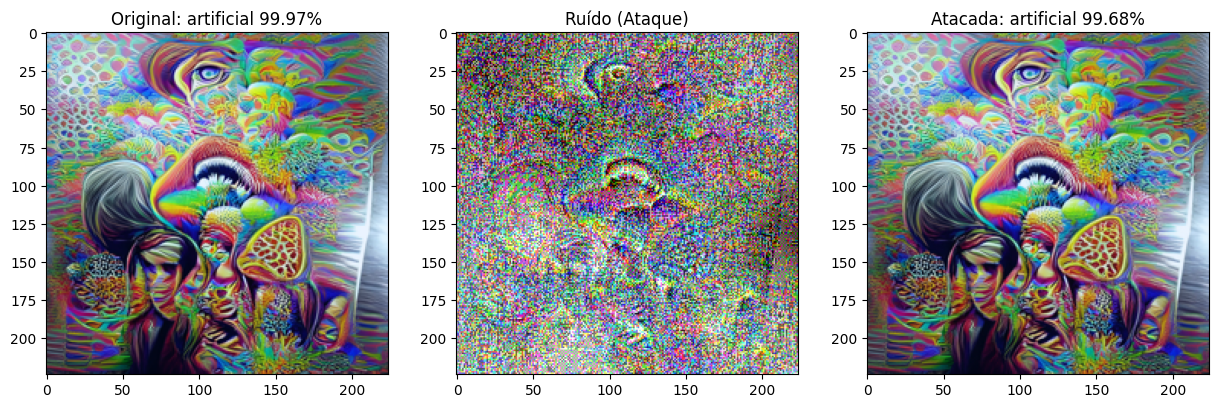

In [94]:
show_comparison()

### Saving some images that fooled our first methods

In [130]:
images_fool_path.append(img_path)

## Define PGD Attack Function



In [90]:
def pgd_attack(model, original_image, epsilon, alpha, num_steps, target_label_id):
    # Initialize the perturbed image with a copy of the original image
    # and ensure it requires gradients for the attack
    perturbed_image = original_image.clone().detach()
    perturbed_image.requires_grad = True

    # Create a tensor for the target label, matching the batch size of the image
    target_tensor = torch.full((original_image.shape[0],), target_label_id, dtype=torch.long, device=original_image.device)

    for _ in range(num_steps):
        # Zero out any gradients from previous iterations to avoid accumulation
        if perturbed_image.grad is not None:
            perturbed_image.grad.zero_()

        # Perform a forward pass through the model with the current perturbed image
        outputs = model(pixel_values=perturbed_image)

        # Calculate the loss, targeting the desired 'human' label
        loss = torch.nn.CrossEntropyLoss()(outputs.logits, target_tensor)

        # Perform a backward pass to compute gradients of the loss with respect to the perturbed image
        loss.backward()

        # Get the sign of the gradients (direction of maximum increase in loss)
        sign_grad = perturbed_image.grad.sign()

        # Update the perturbed image. Operations on `perturbed_image.data` are in-place
        # and do not build new computational graphs, preventing unintended gradient accumulation.
        with torch.no_grad():
            # Add perturbation scaled by alpha
            perturbed_image.data = perturbed_image.data + alpha * sign_grad

            # Project the perturbed image back into an epsilon-ball around the original image
            # This ensures the perturbation doesn't become too large
            delta = perturbed_image.data - original_image.data
            delta = torch.clamp(delta, -epsilon, epsilon)
            perturbed_image.data = original_image.data + delta

            # Clamp the pixel values to the valid range of the original image's distribution
            # This helps in maintaining the visual realism of the image within the model's expected input range
            perturbed_image.data = torch.clamp(perturbed_image.data, original_image.min(), original_image.max())

        # Re-enable gradient tracking for the next iteration
        perturbed_image.requires_grad = True

    return perturbed_image

## Outra abordagem

In [131]:
# Obter média e desvio padrão do processador para fazer o clamp correto
# (Geralmente estão em processor.image_mean e processor.image_std)
mean = torch.tensor(processor.image_mean).to(device).view(1, 3, 1, 1)
std = torch.tensor(processor.image_std).to(device).view(1, 3, 1, 1)

def pgd_attack(model, images, labels, epsilon=0.1, alpha=0.01, num_iter=20):
    """
    Ataque PGD (Projected Gradient Descent) - Mais forte que FGSM
    epsilon: magnitude total do ruído
    alpha: tamanho do passo a cada iteração
    num_iter: número de passos
    """
    original_images = images.clone().detach()

    for i in range(num_iter):
        images.requires_grad = True
        outputs = model(pixel_values=images)

        # Queremos maximizar a perda (fazer o modelo errar)
        loss = torch.nn.CrossEntropyLoss()(outputs.logits, labels)
        model.zero_grad()
        loss.backward()

        # Passo do ataque
        adv_images = images + alpha * images.grad.sign()

        # Projeção: garante que o ruído não exceda epsilon total
        eta = torch.clamp(adv_images - original_images, min=-epsilon, max=epsilon)
        images = original_images + eta

        # Clamp inteligente: Desnormaliza -> Clampa [0,1] -> Renormaliza
        # Isso garante que a imagem final seja válida no "mundo real"
        images = (images * std + mean).clamp(0, 1) # Volta para 0-1 e limita
        images = (images - mean) / std             # Normaliza de volta para o modelo

        # Desconecta o gradiente para a próxima iteração
        images = images.detach()

    return images

# Uso:
# inputs["pixel_values"] já está no device
labels = torch.tensor([orig_pred]).to(device) # O label original que queremos que ele erre

# Tente aumentar o epsilon se necessário (ex: 0.1, 0.2)
perturbed_data = pgd_attack(model, inputs["pixel_values"], labels, epsilon=0.1, alpha=0.01, num_iter=10)

In [132]:
with torch.no_grad():
    pgd_adv_outputs = model(pixel_values=perturbed_data)

pgd_adv_probs = torch.softmax(pgd_adv_outputs.logits, dim=1);
pgd_adv_pred_idx = pgd_adv_probs.argmax(dim=1).item();
pgd_adv_label = model.config.id2label[pgd_adv_pred_idx];
pgd_adv_conf = pgd_adv_probs[0, pgd_adv_pred_idx].item();

print(f"Pós-Ataque PGD: {pgd_adv_label} ({pgd_adv_conf:.2%})")

if pgd_adv_label == 'human':
    print("Success! A IA foi enganada pelo ataque PGD.")
else:
    print("A IA resistiu ao ataque PGD. Tente ajustar os parâmetros (epsilon, alpha, num_steps).")

Pós-Ataque PGD: human (100.00%)
Success! A IA foi enganada pelo ataque PGD.


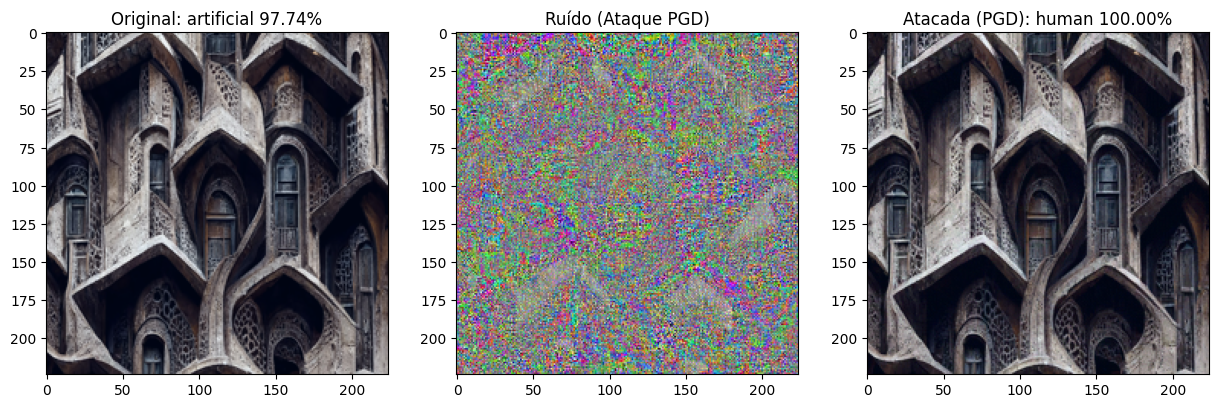

In [135]:
import matplotlib.pyplot as plt

# Extract and convert original and PGD perturbed images
orig_img = inputs["pixel_values"].detach().cpu().squeeze().permute(1, 2, 0).numpy()
pgd_adv_img = perturbed_data.detach().cpu().squeeze().permute(1, 2, 0).numpy()

# Normalize images for display purposes (Matplotlib expects values between 0 and 1 or -1 and 1)
# Ensure original_image.min() and original_image.max() are used for proper scaling if image values are not in [0,1]
# For typical preprocessed images, values might be around [-2, 2] or similar
# A more robust normalization could be to scale to [0,1] based on actual min/max of current tensor

# For display, we can normalize to 0-1 range to prevent 'clipping' warnings and ensure proper colors
# Calculate noise based on the normalized images, or keep it relative to the original scale
# Let's normalize both original and perturbed to [0,1] for display

orig_img_display = (orig_img - orig_img.min()) / (orig_img.max() - orig_img.min())
pgd_adv_img_display = (pgd_adv_img - pgd_adv_img.min()) / (pgd_adv_img.max() - pgd_adv_img.min())

# Calculate the noise (difference between perturbed and original) and normalize for display
noise = pgd_adv_img - orig_img
noise_display = (noise - noise.min()) / (noise.max() - noise.min())

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(orig_img_display); ax[0].set_title(f"Original: {orig_label} {orig_conf:.2%}")
ax[1].imshow(noise_display); ax[1].set_title("Ruído (Ataque PGD)")
ax[2].imshow(pgd_adv_img_display); ax[2].set_title(f"Atacada (PGD): {pgd_adv_label} {pgd_adv_conf:.2%}")
plt.show()

Aplicando ataque PGD em 3 imagens...

[1/3] Processando: zjgkiTBuW5pPg4P7rV8u_4x.jpg
  Original: artificial (99.97%)
  Pós-PGD: human (100.00%)
  ✓ SUCESSO! Imagem classificada como 'human'



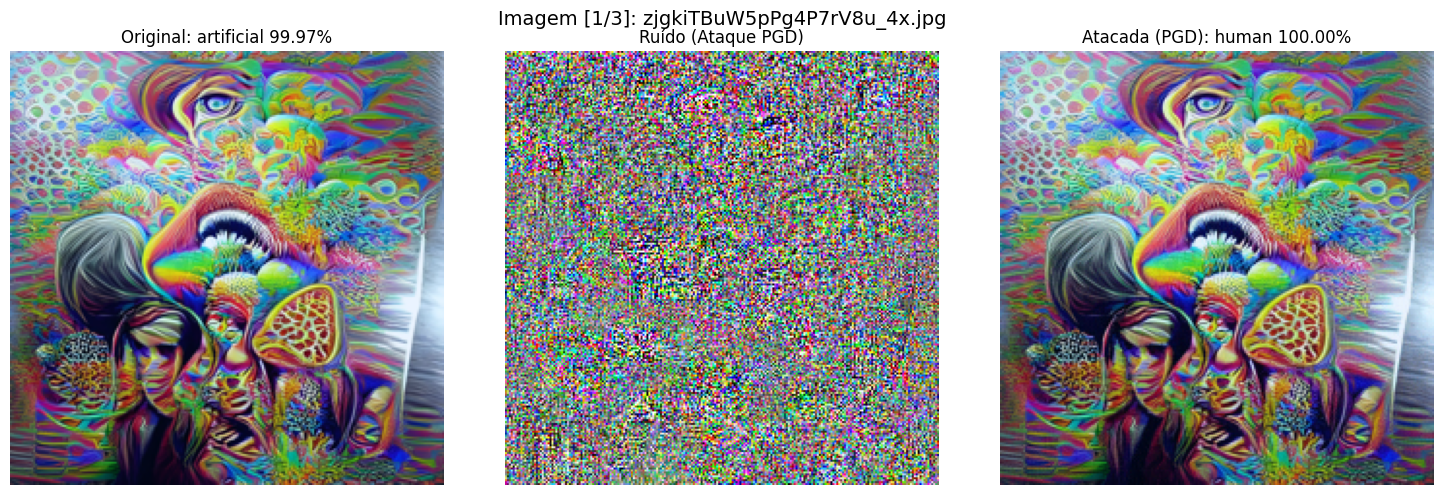

[2/3] Processando: il_570xN.4641411301_ngcf.jpg
  Original: artificial (99.82%)
  Pós-PGD: human (100.00%)
  ✓ SUCESSO! Imagem classificada como 'human'



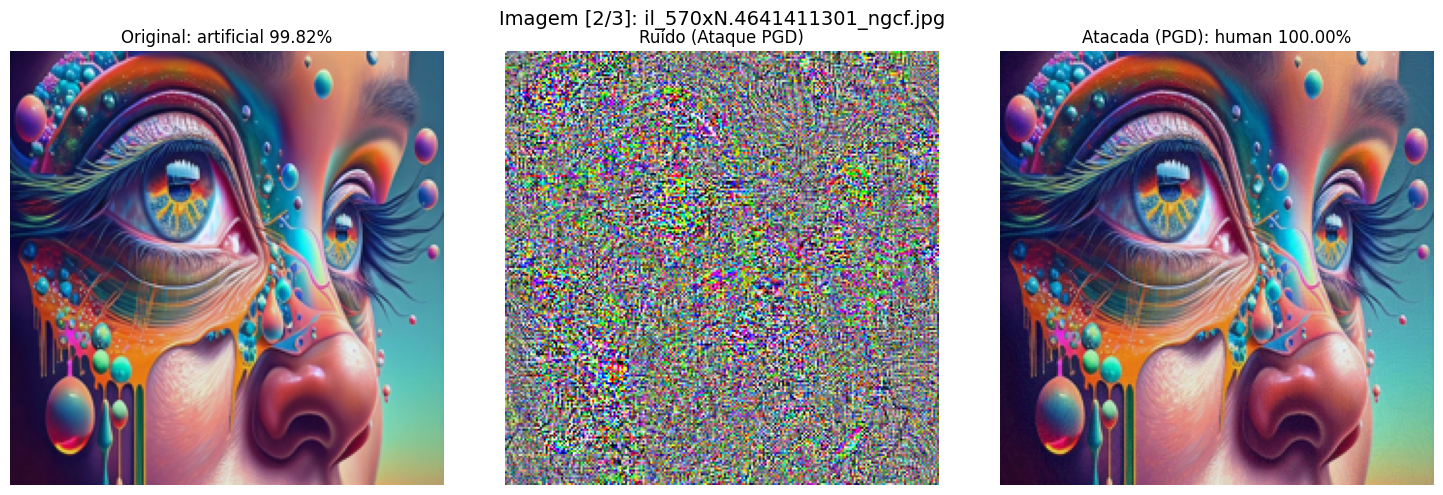

[3/3] Processando: hassan-ragab-cairo-sketches-midjourney-ai-architecture-hero_dezeen_1704_col_0.jpg
  Original: artificial (97.74%)
  Pós-PGD: human (100.00%)
  ✓ SUCESSO! Imagem classificada como 'human'



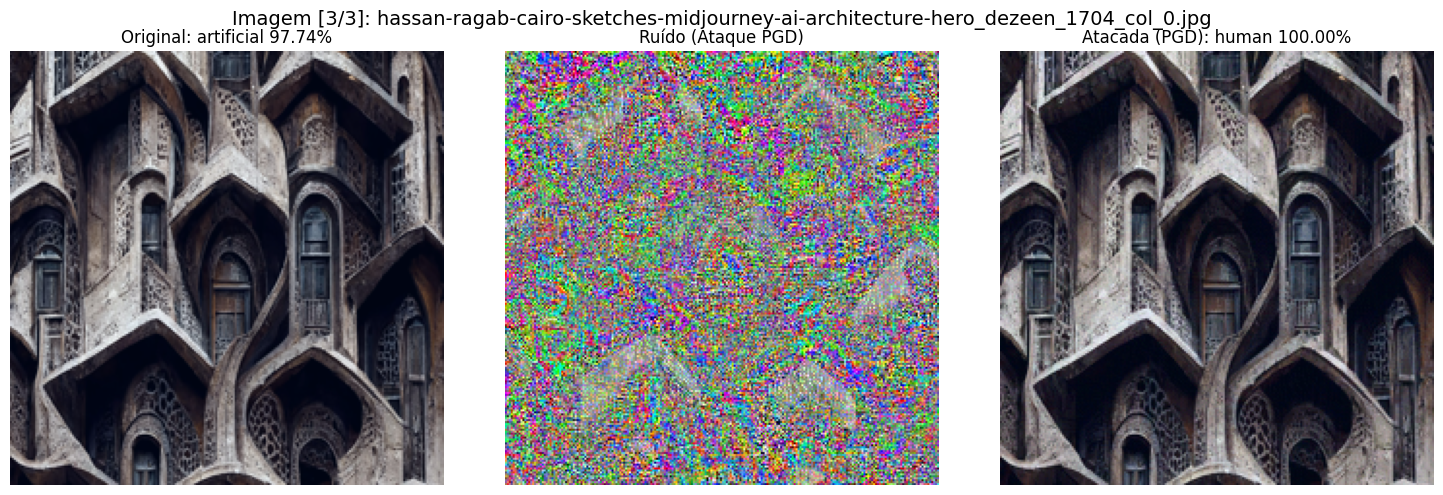

Resumo do Ataque PGD:
  Total de imagens: 3
  Ataques bem-sucedidos: 3
  Taxa de sucesso: 100.0%


In [137]:
# Inicializa a lista se ainda não existir
if 'images_fool_path' not in locals():
    images_fool_path = []

# Parâmetros do ataque PGD
epsilon = 0.1
alpha = 0.01
num_iter = 20

# Obter média e desvio padrão do processador
mean = torch.tensor(processor.image_mean).to(device).view(1, 3, 1, 1)
std = torch.tensor(processor.image_std).to(device).view(1, 3, 1, 1)

# Estatísticas do ataque
total_images = len(images_fool_path)
successful_attacks = 0

print(f"Aplicando ataque PGD em {total_images} imagens...\n")

for idx, img_path in enumerate(images_fool_path):
    print(f"[{idx+1}/{total_images}] Processando: {img_path.name}")
    
    # Carregar e processar a imagem
    image = Image.open(img_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Predição original
    with torch.no_grad():
        outputs = model(**inputs)
        orig_probs = torch.softmax(outputs.logits, dim=1)
        orig_pred = orig_probs.argmax(dim=1).item()
        orig_conf = orig_probs[0, orig_pred].item()
        orig_label = model.config.id2label[orig_pred]
    
    print(f"  Original: {orig_label} ({orig_conf:.2%})")
    
    # Aplicar ataque PGD
    original_images = inputs["pixel_values"].clone().detach()
    perturbed_images = original_images.clone()
    labels = torch.tensor([orig_pred]).to(device)
    
    for i in range(num_iter):
        perturbed_images.requires_grad = True
        outputs = model(pixel_values=perturbed_images)
        
        loss = torch.nn.CrossEntropyLoss()(outputs.logits, labels)
        model.zero_grad()
        loss.backward()
        
        adv_images = perturbed_images + alpha * perturbed_images.grad.sign()
        eta = torch.clamp(adv_images - original_images, min=-epsilon, max=epsilon)
        perturbed_images = original_images + eta
        
        # Clamp inteligente
        perturbed_images = (perturbed_images * std + mean).clamp(0, 1)
        perturbed_images = (perturbed_images - mean) / std
        perturbed_images = perturbed_images.detach()
    
    # Predição pós-ataque
    with torch.no_grad():
        adv_outputs = model(pixel_values=perturbed_images)
        adv_probs = torch.softmax(adv_outputs.logits, dim=1)
        adv_pred = adv_probs.argmax(dim=1).item()
        adv_conf = adv_probs[0, adv_pred].item()
        adv_label = model.config.id2label[adv_pred]
    
    print(f"  Pós-PGD: {adv_label} ({adv_conf:.2%})")
    
    # Verificar sucesso do ataque
    if adv_label == 'human' and orig_label != 'human':
        successful_attacks += 1
        print(f"  ✓ SUCESSO! Imagem classificada como 'human'\n")
    elif orig_label != adv_label:
        print(f"  ⚠ Classificação mudou mas não para 'human'\n")
    else:
        print(f"  ✗ Falhou em mudar a classificação\n")
    
    # Mostrar comparação visual (como na célula 19)
    orig_img = original_images.detach().cpu().squeeze().permute(1, 2, 0).numpy()
    pgd_adv_img = perturbed_images.detach().cpu().squeeze().permute(1, 2, 0).numpy()
    
    # Normalizar para display
    orig_img_display = (orig_img - orig_img.min()) / (orig_img.max() - orig_img.min())
    pgd_adv_img_display = (pgd_adv_img - pgd_adv_img.min()) / (pgd_adv_img.max() - pgd_adv_img.min())
    
    # Calcular ruído
    noise = pgd_adv_img - orig_img
    noise_display = (noise - noise.min()) / (noise.max() - noise.min())
    
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Imagem [{idx+1}/{total_images}]: {img_path.name}", fontsize=14)
    ax[0].imshow(orig_img_display); ax[0].set_title(f"Original: {orig_label} {orig_conf:.2%}")
    ax[1].imshow(noise_display); ax[1].set_title("Ruído (Ataque PGD)")
    ax[2].imshow(pgd_adv_img_display); ax[2].set_title(f"Atacada (PGD): {adv_label} {adv_conf:.2%}")
    for a in ax:
        a.axis('off')
    plt.tight_layout()
    plt.show()

# Resumo final
print("="*60)
print(f"Resumo do Ataque PGD:")
print(f"  Total de imagens: {total_images}")
print(f"  Ataques bem-sucedidos: {successful_attacks}")
print(f"  Taxa de sucesso: {successful_attacks/total_images*100:.1f}%" if total_images > 0 else "  N/A")
print("="*60)